<a href="https://colab.research.google.com/github/Abdulmathin-shaik/watch-tower/blob/main/Exp_Date.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/Products-Real/train')

In [3]:
!ls

annotations.json  desktop.ini  images  labels  labels.cache  yolo11n.pt  yolov8n.pt


In [ ]:
# %% [markdown]
# # Convert Faster R-CNN JSON Annotations to YOLO TXT Format
# This notebook converts Faster R-CNN annotations in JSON format to YOLO format TXT files.

# %% [markdown]
# ## Imports and Setup

# %%
import json
import os
from pathlib import Path

# %% [markdown]
# ## Conversion Function

# %%
def convert_to_yolo(json_path, output_dir, img_dir):
    """
    Convert Faster R-CNN JSON annotations to YOLO TXT format.

    Args:
        json_path (str): Path to the JSON annotation file
        output_dir (str): Directory to save YOLO TXT files
        img_dir (str): Directory containing the images (to get dimensions)
    """
    # Create output directory if it doesn't exist
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Load JSON annotations
    with open(json_path, 'r') as f:
        annotations = json.load(f)

    # Define class mapping (YOLO uses 0-based indices)
    class_names = ['date', 'due']  # Exclude background, add other classes if needed
    class_map = {name: idx for idx, name in enumerate(class_names)}
    print("Class mapping:", class_map)

    # Process each image
    for img_name, data in annotations.items():
        img_width = data['width']
        img_height = data['height']
        txt_path = os.path.join(output_dir, img_name.replace('.jpg', '.txt'))

        yolo_lines = []
        for ann in data['ann']:
            cls_name = ann['cls']
            if cls_name not in class_map:
                print(f"Warning: Skipping unknown class '{cls_name}' in {img_name}")
                continue

            # Convert to YOLO format
            bbox = ann['bbox']  # [xmin, ymin, xmax, ymax]
            x_min, y_min, x_max, y_max = bbox

            # Calculate center coordinates and dimensions
            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2
            width = x_max - x_min
            height = y_max - y_min

            # Normalize by image dimensions
            x_center_norm = x_center / img_width
            y_center_norm = y_center / img_height
            width_norm = width / img_width
            height_norm = height / img_height

            # Validate coordinates
            if not (0 <= x_center_norm <= 1 and 0 <= y_center_norm <= 1 and
                   0 <= width_norm <= 1 and 0 <= height_norm <= 1):
                print(f"Warning: Invalid normalized coordinates in {img_name}: "
                      f"x_center={x_center_norm}, y_center={y_center_norm}, "
                      f"width={width_norm}, height={height_norm}")
                continue

            # Create YOLO format line
            class_id = class_map[cls_name]
            yolo_line = f"{class_id} {x_center_norm:.6f} {y_center_norm:.6f} " \
                       f"{width_norm:.6f} {height_norm:.6f}"
            yolo_lines.append(yolo_line)

        # Write to TXT file
        with open(txt_path, 'w') as f:
            f.write('\n'.join(yolo_lines))
        print(f"Converted {img_name} to {txt_path}")

# %% [markdown]
# ## Execute Conversion

# %%
# Define paths
json_path = "/content/drive/MyDrive/Products-Real/train/annotations.json"
output_dir = "/content/drive/MyDrive/Products-Real/train/yolo_labels"
img_dir = "/content/drive/MyDrive/Products-Real/train/images"

# Run conversion
convert_to_yolo(json_path, output_dir, img_dir)

# %% [markdown]
# ## Verify Output (Optional)

# %%
# Check a sample output
sample_txt = os.path.join(output_dir, "img_00001.txt")
if os.path.exists(sample_txt):
    with open(sample_txt, 'r') as f:
        print(f"Contents of {sample_txt}:")
        print(f.read())

In [7]:
# Define paths
json_path = "/content/drive/MyDrive/Products-Real/evaluation/annotations.json"
output_dir = "/content/drive/MyDrive/Products-Real/evaluation/yolo_labels"
img_dir = "/content/drive/MyDrive/Products-Real/evaluation/images"

In [ ]:
convert_to_yolo(json_path, output_dir, img_dir)


In [3]:
pip install ultralytics easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.6/922.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [1]:
from ultralytics import YOLO

In [6]:
base_dir = "/content/drive/MyDrive/Products-Real"
train_img_dir = os.path.join(base_dir, "train", "images")
train_label_dir = os.path.join(base_dir, "train", "yolo_labels")

In [12]:
# Verify directories exist
print("Images directory exists:", os.path.exists(train_img_dir))
print("Labels directory exists:", os.path.exists(train_label_dir))

Images directory exists: True
Labels directory exists: True


In [8]:
# Define dataset configuration
data_yaml_content = """
train: /content/drive/MyDrive/Products-Real/train/images
val: /content/drive/MyDrive/Products-Real/val/images  # Use train as val for now, update if you have a separate val set
nc: 2  # Number of classes
names: ['date', 'due']  # Class names
"""

# Write to file
yaml_path = os.path.join(base_dir, "data.yaml")
with open(yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"Created {yaml_path}")
print("Contents:")
print(data_yaml_content)

Created /content/drive/MyDrive/Products-Real/data.yaml
Contents:

train: /content/drive/MyDrive/Products-Real/train/images
val: /content/drive/MyDrive/Products-Real/val/images  # Use train as val for now, update if you have a separate val set
nc: 2  # Number of classes
names: ['date', 'due']  # Class names



In [10]:
model = YOLO('yolov8n.pt')  # 'yolov8n.pt' is the nano model, use 'yolov8s.pt', 'yolov8m.pt', etc., for larger models

# Train the model
results = model.train(
    data=yaml_path,      # Path to your data.yaml
    epochs=25,           # Number of epochs
    imgsz=640,           # Image size (adjust based on your images)
    batch=16,            # Batch size (adjust based on GPU memory)
    name='yolo_products', # Name for this training run
    project='/content/drive/MyDrive/Products-Real/runs',  # Where to save results
    device=0             # Use GPU (0 for first GPU)
)

Ultralytics 8.3.86 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Products-Real/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/content/drive/MyDrive/Products-Real/runs, name=yolo_products7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False

train: Scanning /content/drive/MyDrive/Products-Real/train/labels.cache... 1102 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1102/1102 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/Products-Real/val/labels.cache... 665 images, 281 backgrounds, 0 corrupt: 100%|██████████| 665/665 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/Products-Real/runs/yolo_products7/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001667, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/Products-Real/runs/yolo_products7
Starting training for 25 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      18/25      2.08G     0.8097     0.7596     0.9095         26        640: 100%|██████████| 69/69 [00:29<00:00,  2.37it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 21/21 [00:12<00:00,  1.69it/s]

                   all        665        527      0.434      0.779      0.408      0.297



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      19/25      2.01G     0.7924     0.7253      0.903         32        640:  55%|█████▌    | 38/69 [00:16<00:13,  2.33it/s]


KeyboardInterrupt: 

In [11]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

# Train the model with techniques to reduce overfitting
results = model.train(
    data=yaml_path,      # Path to your data.yaml
    epochs=25,           # Number of epochs (adjust if needed)
    imgsz=640,           # Image size (adjust based on your images)
    batch=16,            # Batch size (adjust based on GPU memory)
    name='yolo_products', # Name for this training run
    project='/content/drive/MyDrive/Products-Real/runs',  # Where to save results
    device=0,             # Use GPU (0 for first GPU)

    # **Augmentation Techniques**
    augment=True,        # Enable data augmentation
    fliplr=0.5,          # Probability of horizontal flip
    flipud=0.5,          # Probability of vertical flip
    degrees=10,          # Rotation range in degrees
    translate=0.1,       # Translation range (fraction of image size)
    scale=0.1,           # Scaling range (fraction of image size)
    shear=10,            # Shear range in degrees

    # **Regularization Techniques**
    dropout=0.2,          # Dropout rate (adjust if needed)

    # **Hyperparameter Tuning**
    optimizer='AdamW',    # Use AdamW optimizer
    lr0=0.001,            # Initial learning rate (adjust if needed)
    lrf=0.01,             # Final learning rate (adjust if needed)
    momentum=0.937,      # Momentum for SGD optimizer (if used)
    weight_decay=0.0005,  # Weight decay (L2 regularization)

    # **Early Stopping**
    patience=10,

    )# Number of epochs to wait before stopping if no improvement

Ultralytics 8.3.86 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Products-Real/data.yaml, epochs=25, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/content/drive/MyDrive/Products-Real/runs, name=yolo_products8, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.2, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False,

train: Scanning /content/drive/MyDrive/Products-Real/train/labels.cache... 1102 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1102/1102 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/drive/MyDrive/Products-Real/val/labels.cache... 665 images, 281 backgrounds, 0 corrupt: 100%|██████████| 665/665 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/Products-Real/runs/yolo_products8/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/Products-Real/runs/yolo_products8
Starting training for 25 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      25/25      3.05G     0.7846     0.6845     0.8829         28        640: 100%|██████████| 69/69 [00:31<00:00,  2.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 21/21 [00:13<00:00,  1.57it/s]

                   all        665        527        0.4      0.728      0.371      0.232



25 epochs completed in 0.326 hours.
Optimizer stripped from /content/drive/MyDrive/Products-Real/runs/yolo_products8/weights/last.pt, 6.2MB
Optimizer stripped from /content/drive/MyDrive/Products-Real/runs/yolo_products8/weights/best.pt, 6.2MB

Validating /content/drive/MyDrive/Products-Real/runs/yolo_products8/weights/best.pt...
Ultralytics 8.3.86 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 21/21 [00:15<00:00,  1.39it/s]


                   all        665        527        0.4      0.691      0.355      0.222
                  date         64         68     0.0672      0.868     0.0786     0.0526
                   due        376        459      0.733      0.515      0.631      0.391
Speed: 0.2ms preprocess, 7.8ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/drive/MyDrive/Products-Real/runs/yolo_products8


In [1]:
device = 'cuda'

In [2]:
new_model = YOLO('/content/drive/MyDrive/Products-Real/runs/yolo_products8/weights/best.pt')

In [3]:
import cv2

In [4]:
img = cv2.imread('/content/Screen Shot 2025-03-09 at 1.23.33 PM.png')

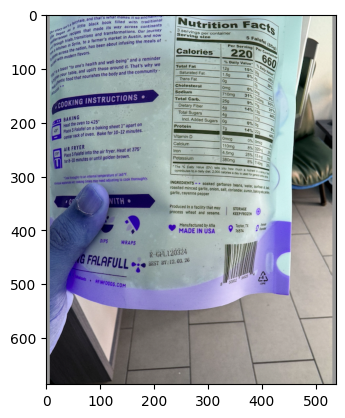

In [5]:
import matplotlib.pyplot as plt
plt.imshow(img)

In [6]:
results = new_model.predict(img)


0: 640x512 1 date, 47.5ms
Speed: 16.5ms preprocess, 47.5ms inference, 357.9ms postprocess per image at shape (1, 3, 640, 512)


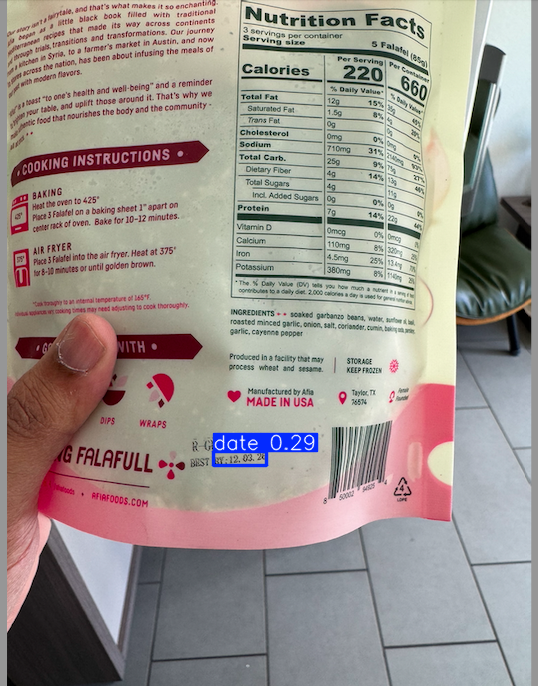

In [7]:
for result in results:
    boxes = result.boxes
    result.show()


In [11]:
img_path = '/content/Screen Shot 2025-03-09 at 1.23.33 PM.png'

In [12]:
img = cv2.imread(img_path)
if img is None:
    raise ValueError(f"Failed to load image: {img_path}")
img_height, img_width = img.shape[:2]

In [16]:
# Extract bounding box for 'date' (class 0)
date_boxes = []
for result in results:
    orig_width, orig_height = result.orig_shape[1], result.orig_shape[0]
    print(f"YOLO processed dimensions: {orig_width}x{orig_height}")

    for box in result.boxes:
        cls_id = int(box.cls[0])
        if cls_id == 0:  # 'date' is class 0
            # Normalized coordinates from YOLO
            x_center, y_center, width, height = box.xywh[0].tolist()
            print(f"Normalized xywh: [{x_center:.4f}, {y_center:.4f}, {width:.4f}, {height:.4f}]")

            # Scale to original image dimensions
            x_center = x_center * orig_width
            y_center = y_center * orig_height
            width = width * orig_width
            height = height * orig_height
            print(f"Pixel xywh: [{x_center:.2f}, {y_center:.2f}, {width:.2f}, {height:.2f}]")

            # Convert to [xmin, ymin, xmax, ymax]
            xmin = x_center - (width / 2)
            ymin = y_center - (height / 2)
            xmax = x_center + (width / 2)
            ymax = y_center + (height / 2)

            # Clamp to image bounds
            xmin = max(0, min(xmin, orig_width))
            ymin = max(0, min(ymin, orig_height))
            xmax = max(0, min(xmax, orig_width))
            ymax = max(0, min(ymax, orig_height))

            if xmin >= xmax or ymin >= ymax:
                print(f"Invalid original box after clamping: [{xmin:.2f}, {ymin:.2f}, {xmax:.2f}, {ymax:.2f}]")
                raise ValueError("Original box coordinates are invalid")

            date_boxes.append([xmin, ymin, xmax, ymax])

if not date_boxes:
    raise ValueError("No 'date' bounding box detected in the image")

xmin, ymin, xmax, ymax = date_boxes[0]
print(f"Original date box: [{xmin:.2f}, {ymin:.2f}, {xmax:.2f}, {ymax:.2f}]")

YOLO processed dimensions: 538x686
Normalized xywh: [239.7292, 458.4823, 52.6383, 14.3174]
Pixel xywh: [128974.32, 314518.86, 28319.41, 9821.70]
Invalid original box after clamping: [538.00, 686.00, 538.00, 686.00]


ValueError: Original box coordinates are invalid

In [14]:
# %%
width = xmax - xmin
height = ymax - ymin
expand_w = width * 0.15
expand_h = height * 0.15

new_xmin = max(0, xmin - expand_w)
new_ymin = max(0, ymin - expand_h)
new_xmax = min(img_width, xmax + expand_w)
new_ymax = min(img_height, ymax + expand_h)

if new_xmin > new_xmax:
    new_xmin, new_xmax = new_xmax, new_xmin
if new_ymin > new_ymax:
    new_ymin, new_ymax = new_ymax, new_ymin

print(f"Expanded date box: [{new_xmin:.2f}, {new_ymin:.2f}, {new_xmax:.2f}, {new_ymax:.2f}]")

Expanded date box: [538.00, 686.00, 110566.70, 308134.75]


In [15]:
# Convert to integer coordinates for cropping
new_xmin, new_ymin = int(new_xmin), int(new_ymin)
new_xmax, new_ymax = int(new_xmax), int(new_ymax)

# Crop the image (OpenCV uses [y:y+h, x:x+w])
cropped_img = img[new_ymin:new_ymax, new_xmin:new_xmax]

# Check if crop resulted in an empty image
if cropped_img.size == 0:
    raise ValueError(f"Crop resulted in empty image. Coordinates: [{new_xmin}, {new_ymin}, {new_xmax}, {new_ymax}]")

# %% [markdown]
# ## Step 6: Display and Save the Cropped Image

# %%
# Convert BGR to RGB for matplotlib display
cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

# Display using matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(cropped_img_rgb)
plt.axis('off')
plt.title("Cropped Date Region")
plt.show()

ValueError: Crop resulted in empty image. Coordinates: [538, 686, 110566, 308134]

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

In [11]:
img.size

1107204

In [12]:
img_path = '/content/Screen Shot 2025-03-09 at 1.23.33 PM.png'

In [13]:
# Load original image
img = Image.open(img_path)
img_width, img_height = img.size

In [14]:
# Extract bounding box for 'date' (class 0)
date_boxes = []
for result in results:
    # Get image dimensions from result (in case YOLO resizes)
    orig_width, orig_height = result.orig_shape[1], result.orig_shape[0]
    print(f"YOLO processed dimensions: {orig_width}x{orig_height}")

    for box in result.boxes:
        cls_id = int(box.cls[0])
        if cls_id == 0:  # 'date' is class 0
            # YOLO format: [x_center, y_center, width, height] (normalized)
            x_center, y_center, width, height = box.xywh[0].tolist()
            print(f"Normalized xywh: [{x_center:.4f}, {y_center:.4f}, {width:.4f}, {height:.4f}]")

            # Convert from normalized to pixel coordinates using original image size
            x_center *= orig_width
            y_center *= orig_height
            width *= orig_width
            height *= orig_height
            print(f"Pixel xywh: [{x_center:.2f}, {y_center:.2f}, {width:.2f}, {height:.2f}]")

            # Convert to [xmin, ymin, xmax, ymax]
            xmin = x_center - (width / 2)
            ymin = y_center - (height / 2)
            xmax = x_center + (width / 2)
            ymax = y_center + (height / 2)

            # Validate original coordinates
            if xmin > xmax or ymin > ymax:
                print(f"Invalid original box: [{xmin:.2f}, {ymin:.2f}, {xmax:.2f}, {ymax:.2f}]")
                raise ValueError("Original box coordinates are invalid")

            date_boxes.append([xmin, ymin, xmax, ymax])

if not date_boxes:
    raise ValueError("No 'date' bounding box detected in the image")

YOLO processed dimensions: 538x686
Normalized xywh: [239.7292, 458.4823, 52.6383, 14.3174]
Pixel xywh: [128974.32, 314518.86, 28319.41, 9821.70]


In [15]:
# Use the first detected 'date' box
xmin, ymin, xmax, ymax = date_boxes[0]
print(f"Original date box: [{xmin:.2f}, {ymin:.2f}, {xmax:.2f}, {ymax:.2f}]")

Original date box: [114814.61, 309608.01, 143134.02, 319429.71]


In [16]:
# Calculate expansion (15% of the width and height)
width = xmax - xmin
height = ymax - ymin
expand_w = width * 0.15
expand_h = height * 0.15

# Expand coordinates
new_xmin = max(0, xmin - expand_w)
new_ymin = max(0, ymin - expand_h)
new_xmax = min(img_width, xmax + expand_w)
new_ymax = min(img_height, ymax + expand_h)

# Ensure coordinates are valid
if new_xmin > new_xmax:
    new_xmin, new_xmax = new_xmax, new_xmin
if new_ymin > new_ymax:
    new_ymin, new_ymax = new_ymax, new_ymin

print(f"Expanded date box: [{new_xmin:.2f}, {new_ymin:.2f}, {new_xmax:.2f}, {new_ymax:.2f}]")

Expanded date box: [538.00, 686.00, 110566.70, 308134.75]


In [17]:
Image.MAX_IMAGE_PIXELS = None  # Remove limit (use with caution)

In [ ]:
cropped_img = img.crop((new_xmin, new_ymin, new_xmax, new_ymax))

In [ ]:
plt.imshow(cropped_img)

In [ ]:
import easy